# ED Triage AI — Feature Engineering Notebook

Transforms the cleaned dataset into model-ready features. No train/test splitting or text embedding occurs here.

**Input:** `s3://ed-triage-capstone-group7/Data_Output/consolidated_dataset_cleaned.csv`
**Output:** `s3://ed-triage-capstone-group7/Data_Output/consolidated_dataset_features.csv`

## Section Map
| Section | Content |
|---------|---------|
| 1 | Imports & data load |
| 2 | Preserve original columns |
| 3 | Vital signs features (imputation, scaling, derived flags) |
| 4 | Demographics & categorical features (age, gender, race, transport) |
| 5 | Pain features (imputation, scaling, severity bins, interaction) |
| 6 | Text features (combined_text, text statistics) |
| 7 | Target variable analysis (class weights, encoded target) |
| 8 | Final assembly & validation |
| 9 | Save to S3 |

In [21]:
import os
import io
import pickle
import warnings

import boto3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sklearn.preprocessing import StandardScaler, OneHotEncoder

warnings.filterwarnings('ignore')
load_dotenv()
%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")

# ── AWS Config ─────────────────────────────────────────────────────────────────
AWS_PROFILE = os.getenv("AWS_PROFILE", "ed-triage")
AWS_REGION  = os.getenv("AWS_REGION",  "us-east-1")
S3_BUCKET   = os.getenv("S3_BUCKET",   "ed-triage-capstone-group7")

session = boto3.Session(profile_name=AWS_PROFILE, region_name=AWS_REGION)
s3      = session.client("s3")

def read_csv_from_s3(key: str) -> pd.DataFrame:
    """Download a CSV from S3 and return it as a DataFrame."""
    obj = s3.get_object(Bucket=S3_BUCKET, Key=key)
    return pd.read_csv(io.BytesIO(obj["Body"].read()))

# ── Load cleaned dataset from S3 ───────────────────────────────────────────────
INPUT_KEY = "Data_Output/consolidated_dataset_cleaned.csv"
df = read_csv_from_s3(INPUT_KEY)
print(f"Loaded from s3://{S3_BUCKET}/{INPUT_KEY}")
print(f"Shape: {df.shape}")
df.head(3)

Loaded from s3://ed-triage-capstone-group7/Data_Output/consolidated_dataset_cleaned.csv
Shape: (8383, 21)


,stay_id,triage,chiefcomplaint,HPI,past_medical_history,initial_vitals,patient_info,pain,arrival_transport,temp_f,...,resp_rate,spo2,sbp,dbp,vitals_any_missing,vitals_out_of_range,age,gender,race,pain_missing
0,32822973,2,LETHARGY/shortness of breath,Patient is an [REDACTED] year-old patient with...,Anemia\nBorderline cholesterol\nC. Diff\nFlatu...,"Temperature: 100.2, Heartrate: 95.0, resprate:...","Gender: Female, Race: WHITE, Age: 80",0.0,AMBULANCE,100.2,...,28.0,100.0,99.0,47.0,False,False,80,Female,WHITE,1
1,31591237,2,SEVERE abdominal PAIN,[REDACTED] year old male with history to intes...,1. Sarcoidosis<comma> dx skin bx: intestinal &...,"Temperature: 97.8, Heartrate: 87.0, resprate: ...","Gender: Male, Race: WHITE, Age: 69",10.0,WALK IN,97.8,...,26.0,99.0,119.0,63.0,False,False,69,Male,WHITE,0
2,36819102,3,R Leg pain,[REDACTED] w Rt AK pop to [REDACTED] bypass wi...,PMH: DVT R pop v ([REDACTED])<comma> asthma<co...,"Temperature: 98.7, Heartrate: 93.0, resprate: ...","Gender: Female, Race: WHITE, Age: 66",5.0,WALK IN,98.7,...,16.0,99.0,166.0,97.0,False,False,66,Female,WHITE,0


## Section 3 — Vital Signs Features

Imputation → Clinical plausibility clipping → Scaling → Derived features → Binary flags

> **Clinically plausible bound clipping was used instead of standard IQR
> values like HR > 120 or SpO2 < 90 — exactly the abnormalities that signal high-acuity triage.

In [22]:
# ── 3.1  Vital Signs — Imputation + Clinical Plausibility Clipping ────────────
# NOTE: Raw vital columns in df are intentionally NOT modified here.
# df_vitals_proc is a working copy used for all downstream engineered features.
# This ensures the saved CSV preserves original NaN values and unclipped values
# so training pipelines can apply their own train-split imputation correctly.

VITAL_COLS = ['temp_f', 'heart_rate', 'resp_rate', 'spo2', 'sbp', 'dbp']

# Compute global medians from raw data (NaN-aware; reference only)
# NOTE: refit on X_train only at training time to avoid data leakage
vital_medians = {col: df[col].median() for col in VITAL_COLS}
print("Global medians (reference — refit on X_train at training time):")
for col, med in vital_medians.items():
    print(f"  {col}: {med:.2f}")
print(f"\nRaw null counts (preserved): {df[VITAL_COLS].isna().sum().to_dict()}")

# ── Working copy for all derived feature computation ──────────────────────────
# df[VITAL_COLS] is UNCHANGED throughout this notebook.
df_vitals_proc = df[VITAL_COLS].copy()

for col in VITAL_COLS:
    df_vitals_proc[col] = df_vitals_proc[col].fillna(vital_medians[col])

# Clinical plausibility bounds — deliberately wide to preserve actionable extremes
CLINICAL_CLIP_BOUNDS = {
    'heart_rate': (20,  250),   # impossible below 20 or above 250 bpm
    'resp_rate':  (4,   60),    # impossible below 4 or above 60 brpm
    'spo2':       (50,  100),   # cannot exceed 100%; below 50% is entry error
    'sbp':        (40,  300),   # compatible-with-life range
    'dbp':        (10,  200),   # compatible-with-life range
    'temp_f':     (85,  115),   # F: 85=severe hypothermia; 115=extreme hyperthermia
}

clip_bounds_applied = {}
for col, (lo, hi) in CLINICAL_CLIP_BOUNDS.items():
    n_clipped = ((df_vitals_proc[col] < lo) | (df_vitals_proc[col] > hi)).sum()
    df_vitals_proc[col] = df_vitals_proc[col].clip(lower=lo, upper=hi)
    clip_bounds_applied[col] = (lo, hi, n_clipped)

print("\nClinical plausibility clip bounds (applied to df_vitals_proc only):")
print(f"  {'Column':<12} {'Lower':>8} {'Upper':>8}  {'# Clipped':>10}")
print(f"  {'-'*44}")
for col, (lo, hi, n) in clip_bounds_applied.items():
    print(f"  {col:<12} {lo:>8.1f} {hi:>8.1f}  {n:>10,}")

print("\nPost-clip descriptive stats (df_vitals_proc):")
print(df_vitals_proc[VITAL_COLS].describe().round(2))

Global medians (reference — refit on X_train at training time):
  temp_f: 98.10
  heart_rate: 84.00
  resp_rate: 18.00
  spo2: 99.00
  sbp: 133.00
  dbp: 76.00

Raw null counts (preserved): {'temp_f': 169, 'heart_rate': 18, 'resp_rate': 115, 'spo2': 94, 'sbp': 32, 'dbp': 48}

Clinical plausibility clip bounds (applied to df_vitals_proc only):
  Column          Lower    Upper   # Clipped
  --------------------------------------------
  heart_rate       20.0    250.0           3
  resp_rate         4.0     60.0           0
  spo2             50.0    100.0           5
  sbp              40.0    300.0          11
  dbp              10.0    200.0          13
  temp_f           85.0    115.0           8

Post-clip descriptive stats (df_vitals_proc):
        temp_f  heart_rate  resp_rate     spo2      sbp      dbp
count  8383.00     8383.00    8383.00  8383.00  8383.00  8383.00
mean     98.16       85.34      17.56    98.08   134.55    76.25
std       1.05       17.95       2.31     2.44    2

In [23]:
# ── 3.2  Vital Signs — StandardScaler ─────────────────────────────────────────
# Fitted on df_vitals_proc (imputed + clipped working copy), not on raw df.
# NOTE: This scaler is fitted on the full dataset — refit on X_train only at
# training time to avoid data leakage. The *_scaled columns in the output CSV
# are reference features only; training pipelines must refit their own scaler.

vitals_scaler = StandardScaler()
vitals_scaled = vitals_scaler.fit_transform(df_vitals_proc[VITAL_COLS])

for i, col in enumerate(VITAL_COLS):
    df[f'{col}_scaled'] = vitals_scaled[:, i]

SCALER_KEY = "Data_Output/scalers/vitals_scaler.pkl"
s3.put_object(
    Bucket=S3_BUCKET,
    Key=SCALER_KEY,
    Body=pickle.dumps(vitals_scaler),
    ContentType="application/octet-stream",
)
print(f"Vitals scaler saved → s3://{S3_BUCKET}/{SCALER_KEY}")
print("NOTE: scaler fitted on full dataset; refit on X_train only at training time.")

Vitals scaler saved → s3://ed-triage-capstone-group7/Data_Output/scalers/vitals_scaler.pkl
NOTE: scaler fitted on full dataset; refit on X_train only at training time.


In [24]:
# ── 3.3  Vital Signs — Derived Features ───────────────────────────────────────
# All features computed from df_vitals_proc (imputed + clipped working copy).
# Raw df[VITAL_COLS] is untouched.

# Composite physiologic indices
df['shock_index']    = df_vitals_proc['heart_rate'] / df_vitals_proc['sbp']
df['pulse_pressure'] = df_vitals_proc['sbp'] - df_vitals_proc['dbp']
df['map']            = (df_vitals_proc['sbp'] + 2 * df_vitals_proc['dbp']) / 3

# Binary abnormality flags (clinical thresholds)
df['spo2_abnormal']    = (df_vitals_proc['spo2'] < 95).astype(int)
df['hr_tachycardia']   = (df_vitals_proc['heart_rate'] > 100).astype(int)
df['rr_tachypnea']     = (df_vitals_proc['resp_rate'] > 20).astype(int)
df['temp_fever']       = (df_vitals_proc['temp_f'] > 100.4).astype(int)
df['temp_hypothermia'] = (df_vitals_proc['temp_f'] < 96.8).astype(int)
df['hypotension']      = (df_vitals_proc['sbp'] < 90).astype(int)

# vitals_any_missing and vitals_out_of_range come from cleaned CSV — preserve as-is
df['vitals_any_missing']  = df['vitals_any_missing'].astype(int)
df['vitals_out_of_range'] = df['vitals_out_of_range'].astype(int)

# Aggregate abnormality count
# -1 = vitals missing (unknown — do NOT interpret as normal)
#  0 = all vitals measured, none abnormal
# 1–6 = number of abnormal vitals measured
flag_cols = ['spo2_abnormal', 'hr_tachycardia', 'rr_tachypnea',
             'temp_fever', 'temp_hypothermia', 'hypotension']
df['vital_abnormality_count'] = df[flag_cols].sum(axis=1)
df.loc[df['vitals_any_missing'] == 1, 'vital_abnormality_count'] = -1

print(df[['shock_index', 'pulse_pressure', 'map'] + flag_cols + ['vital_abnormality_count']].describe().round(3))

print("\nVital abnormality count distribution:")
labels = {-1: '-1 (unknown)', 0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6'}
print(df['vital_abnormality_count'].value_counts().sort_index().rename(labels).to_string())

       shock_index  pulse_pressure       map  spo2_abnormal  hr_tachycardia  \
count     8383.000        8383.000  8383.000       8383.000        8383.000   
mean         0.654          58.300    95.682          0.054           0.181   
std          0.186          21.553    15.254          0.225           0.385   
min          0.122        -160.000    20.000          0.000           0.000   
25%          0.526          44.000    85.667          0.000           0.000   
50%          0.633          56.000    95.333          0.000           0.000   
75%          0.752          70.000   104.667          0.000           0.000   
max          2.900         224.000   190.333          1.000           1.000   

       rr_tachypnea  temp_fever  temp_hypothermia  hypotension  \
count      8383.000    8383.000          8383.000     8383.000   
mean          0.046       0.021             0.050        0.009   
std           0.209       0.144             0.218        0.095   
min           0.000     

In [25]:
# ── 3.4a  NEWS2 (National Early Warning Score 2) ─────────────────────────────
# Computed from df_vitals_proc (imputed + clipped). Temp thresholds converted °C → °F.
# AVPU/consciousness not available — score omits that component (max 15 instead of 18).

def compute_news2(row):
    """NEWS2 aggregate score (Scale 1 / non-hypercapnic SpO2)."""
    score = 0

    rr = row['resp_rate']
    if   rr <= 8:   score += 3
    elif rr <= 11:  score += 1
    elif rr <= 20:  score += 0
    elif rr <= 24:  score += 2
    else:           score += 3   # ≥25

    spo2 = row['spo2']
    if   spo2 <= 91:  score += 3
    elif spo2 <= 93:  score += 2
    elif spo2 <= 95:  score += 1
    else:             score += 0  # ≥96

    sbp = row['sbp']
    if   sbp <= 90:   score += 3
    elif sbp <= 100:  score += 2
    elif sbp <= 110:  score += 1
    elif sbp <= 219:  score += 0
    else:             score += 3  # ≥220

    hr = row['heart_rate']
    if   hr <= 40:   score += 3
    elif hr <= 50:   score += 1
    elif hr <= 90:   score += 0
    elif hr <= 110:  score += 1
    elif hr <= 130:  score += 2
    else:            score += 3   # ≥131

    temp = row['temp_f']
    if   temp <= 95.0:    score += 3   # ≤35.0°C
    elif temp <= 96.8:    score += 1   # 35.1–36.0°C
    elif temp <= 100.4:   score += 0   # 36.1–38.0°C
    elif temp <= 102.2:   score += 1   # 38.1–39.0°C
    else:                 score += 2   # ≥39.1°C

    return score

df['news2_score'] = df_vitals_proc.apply(compute_news2, axis=1)

# NEWS2 clinical risk tier (0=Low 0–4, 1=Medium 5–6, 2=High ≥7)
df['news2_risk'] = pd.cut(
    df['news2_score'], bins=[-1, 4, 6, 99], labels=[0, 1, 2]
).astype(int)

print("NEWS2 score distribution:")
print(df['news2_score'].describe().round(2).to_string())
print(f"\nNEWS2 risk tier distribution:")
risk_labels = {0: 'Low (0–4)', 1: 'Medium (5–6)', 2: 'High (≥7)'}
print(df['news2_risk'].value_counts().sort_index().rename(risk_labels).to_string())

NEWS2 score distribution:
count    8383.00
mean        0.99
std         1.27
min         0.00
25%         0.00
50%         1.00
75%         2.00
max        10.00

NEWS2 risk tier distribution:
news2_risk
Low (0–4)       8209
Medium (5–6)     144
High (≥7)         30


In [26]:
# ── 3.4b  qSOFA (Quick Sequential Organ Failure Assessment) ──────────────────
# Partial score (0–2): GCS/mental status unavailable, so only RR and SBP criteria used.

df['qsofa_score'] = (
    (df_vitals_proc['resp_rate'] >= 22).astype(int) +
    (df_vitals_proc['sbp'] <= 100).astype(int)
)

print("qSOFA (partial, 0–2) distribution:")
print(df['qsofa_score'].value_counts().sort_index().to_string())

# ── 3.4c  MEWS (Modified Early Warning Score) ─────────────────────────────────
# Subbe et al. (2001). AVPU not available — consciousness component omitted.
# Total range: 0–12 (without consciousness; 0–14 with AVPU).

def compute_mews(row):
    """MEWS aggregate score (without AVPU consciousness component)."""
    score = 0

    sbp = row['sbp']
    if   sbp < 70:    score += 3
    elif sbp < 81:    score += 2
    elif sbp < 101:   score += 1
    elif sbp < 200:   score += 0
    else:             score += 2   # ≥200

    hr = row['heart_rate']
    if   hr < 40:     score += 2
    elif hr < 51:     score += 1
    elif hr < 101:    score += 0
    elif hr < 111:    score += 1
    elif hr < 130:    score += 2
    else:             score += 3   # ≥130

    rr = row['resp_rate']
    if   rr < 9:      score += 2
    elif rr < 15:     score += 0
    elif rr < 21:     score += 1
    elif rr < 30:     score += 2
    else:             score += 3   # ≥30

    temp = row['temp_f']
    if   temp < 95.0:    score += 2   # <35°C
    elif temp <= 101.1:  score += 0   # 35–38.4°C
    else:                score += 2   # ≥38.5°C

    return score

df['mews_score'] = df_vitals_proc.apply(compute_mews, axis=1)

print("\nMEWS score distribution:")
print(df['mews_score'].describe().round(2).to_string())

qSOFA (partial, 0–2) distribution:
qsofa_score
0    7629
1     732
2      22

MEWS score distribution:
count    8383.00
mean        1.39
std         0.89
min         0.00
25%         1.00
50%         1.00
75%         2.00
max         8.00


In [27]:
# ── 3.4d  Clinical Scores — Validation & Distribution by Triage Level ────────
clinical_score_cols = ['news2_score', 'news2_risk', 'qsofa_score', 'mews_score']

assert df[clinical_score_cols].isna().sum().sum() == 0, "NaN in clinical scores!"

print("=== Clinical Scores by Triage Level ===\n")
for col in ['news2_score', 'qsofa_score', 'mews_score']:
    print(f"{col} — mean by triage level:")
    means = df.groupby('triage')[col].mean()
    for level, val in means.items():
        label = {1: 'L1-Critical', 2: 'L2-Emergent', 3: 'L3-Urgent', 4: 'L4-LessUrgent'}[level]
        print(f"  {label}: {val:.3f}")
    print()

print(f"  news2_score — mean: {df['news2_score'].mean():.3f}, max: {df['news2_score'].max()}")
print(f"  mews_score  — mean: {df['mews_score'].mean():.3f}, max: {df['mews_score'].max()}")
print(f"  qsofa_score — mean: {df['qsofa_score'].mean():.3f}, max: {df['qsofa_score'].max()}")

=== Clinical Scores by Triage Level ===

news2_score — mean by triage level:
  L1-Critical: 2.357
  L2-Emergent: 1.098
  L3-Urgent: 0.785
  L4-LessUrgent: 0.649

qsofa_score — mean by triage level:
  L1-Critical: 0.295
  L2-Emergent: 0.125
  L3-Urgent: 0.051
  L4-LessUrgent: 0.018

mews_score — mean by triage level:
  L1-Critical: 2.390
  L2-Emergent: 1.440
  L3-Urgent: 1.257
  L4-LessUrgent: 1.123

  news2_score — mean: 0.994, max: 10
  mews_score  — mean: 1.392, max: 8
  qsofa_score — mean: 0.093, max: 2


In [28]:
# ── 3.5  Vital Signs — Validation ─────────────────────────────────────────────
# Raw vitals: NaN is preserved (intentional — not modified in-place)
print("Raw vital null counts (NaN preserved from cleaning — expected):")
print(df[VITAL_COLS].isna().sum().to_string())

# Processed working copy must be fully clean
assert df_vitals_proc[VITAL_COLS].isna().sum().sum() == 0, \
    "df_vitals_proc has unexpected NaN — check imputation in cell 3.1"

vitals_feature_cols = (
    [f'{c}_scaled' for c in VITAL_COLS] +
    ['shock_index', 'pulse_pressure', 'map',
     'spo2_abnormal', 'hr_tachycardia', 'rr_tachypnea',
     'temp_fever', 'temp_hypothermia', 'hypotension',
     'vital_abnormality_count', 'vitals_any_missing', 'vitals_out_of_range',
     'news2_score', 'news2_risk', 'qsofa_score', 'mews_score']
)

print(f"\nShape: {df.shape}")
print("\nNull counts (vitals feature cols):")
print(df[vitals_feature_cols].isna().sum().to_string())

assert df['shock_index'].isna().sum() == 0
assert df['vital_abnormality_count'].between(-1, 6).all()
assert (df['vitals_any_missing'] == 1).sum() == (df['vital_abnormality_count'] == -1).sum(), \
    "vitals_any_missing and vital_abnormality_count=-1 counts do not match"
assert df[['news2_score', 'qsofa_score', 'mews_score']].isna().sum().sum() == 0

n_unknown = (df['vital_abnormality_count'] == -1).sum()
print(f"\n  vital_abnormality_count=-1 (unknown): {n_unknown} patients")
print(f"  shock_index — mean: {df['shock_index'].mean():.3f}, max: {df['shock_index'].max():.3f}")
print(f"  news2_score — mean: {df['news2_score'].mean():.3f}, max: {df['news2_score'].max()}")
print(f"  mews_score  — mean: {df['mews_score'].mean():.3f}, max: {df['mews_score'].max()}")
print(f"  qsofa_score — mean: {df['qsofa_score'].mean():.3f}, max: {df['qsofa_score'].max()}")

Raw vital null counts (NaN preserved from cleaning — expected):
temp_f        169
heart_rate     18
resp_rate     115
spo2           94
sbp            32
dbp            48

Shape: (8383, 41)

Null counts (vitals feature cols):
temp_f_scaled              0
heart_rate_scaled          0
resp_rate_scaled           0
spo2_scaled                0
sbp_scaled                 0
dbp_scaled                 0
shock_index                0
pulse_pressure             0
map                        0
spo2_abnormal              0
hr_tachycardia             0
rr_tachypnea               0
temp_fever                 0
temp_hypothermia           0
hypotension                0
vital_abnormality_count    0
vitals_any_missing         0
vitals_out_of_range        0
news2_score                0
news2_risk                 0
qsofa_score                0
mews_score                 0

  vital_abnormality_count=-1 (unknown): 362 patients
  shock_index — mean: 0.654, max: 2.900
  news2_score — mean: 0.994, max: 10
  me

## Section 4 — Demographics & Categorical Features

Age scaling + binning → Gender one-hot → Race one-hot → Transport ordinal + one-hot

In [29]:
# ── 4.1  Age — Scaling + Binning ──────────────────────────────────────────────
# TODO: refit scaler on X_train only before model training
# age has 0 NaN in cleaned dataset (int64), but fillna kept for robustness

age_median = df['age'].median()
df['age'] = df['age'].fillna(age_median)  # no-op here; safe for future data

age_scaler = StandardScaler()
df['age_scaled'] = age_scaler.fit_transform(df[['age']])  # TODO: refit on X_train only

SCALER_KEY = "Data_Output/scalers/age_scaler.pkl"
s3.put_object(
    Bucket=S3_BUCKET,
    Key=SCALER_KEY,
    Body=pickle.dumps(age_scaler),
    ContentType="application/octet-stream",
)
print(f"Age scaler saved → s3://{S3_BUCKET}/{SCALER_KEY}")

# Ordinal age bins: 0=pediatric, 1=young adult, 2=middle-aged, 3=senior, 4=elderly
df['age_group'] = pd.cut(
    df['age'],
    bins=[-1, 17, 44, 64, 79, 200],
    labels=[0, 1, 2, 3, 4]
).astype(int)

print(f"\nAge stats — median: {age_median:.1f}")
print("\nAge group distribution:")
print(df['age_group'].value_counts().sort_index().rename(
    {0: '0 (0-17)', 1: '1 (18-44)', 2: '2 (45-64)', 3: '3 (65-79)', 4: '4 (80+)'}
).to_string())

Age scaler saved → s3://ed-triage-capstone-group7/Data_Output/scalers/age_scaler.pkl

Age stats — median: 58.0

Age group distribution:
age_group
1 (18-44)    2259
2 (45-64)    2913
3 (65-79)    1950
4 (80+)      1261


In [30]:
# ── 4.2  Gender — One-Hot Encoding ────────────────────────────────────────────
# 2 categories in data (Female, Male); Unknown=0 in both if encountered
df['gender_female'] = (df['gender'] == 'Female').astype(int)
df['gender_male']   = (df['gender'] == 'Male').astype(int)

print("Gender encoding:")
print(df[['gender', 'gender_female', 'gender_male']].value_counts().to_string())

Gender encoding:
gender  gender_female  gender_male
Female  1              0              4403
Male    0              1              3980


In [31]:
# ── 4.3  Race — One-Hot Encoding ──────────────────────────────────────────────
# TODO: refit encoder on X_train only before model training
race_encoder = OneHotEncoder(
    categories=[['WHITE', 'BLACK', 'HISPANIC', 'ASIAN', 'OTHER']],
    handle_unknown='ignore',
    sparse_output=False
)
race_encoded = race_encoder.fit_transform(df[['race']])
race_cols = ['race_white', 'race_black', 'race_hispanic', 'race_asian', 'race_other']
for i, col in enumerate(race_cols):
    df[col] = race_encoded[:, i].astype(int)

SCALER_KEY = "Data_Output/scalers/race_encoder.pkl"
s3.put_object(
    Bucket=S3_BUCKET,
    Key=SCALER_KEY,
    Body=pickle.dumps(race_encoder),
    ContentType="application/octet-stream",
)

assert df[race_cols].sum(axis=1).eq(1).all(), "Race one-hot rows do not sum to 1"
print(f"Race encoder saved → s3://{S3_BUCKET}/{SCALER_KEY}")
print(df[race_cols].sum().to_string())

Race encoder saved → s3://ed-triage-capstone-group7/Data_Output/scalers/race_encoder.pkl
race_white       6000
race_black       1082
race_hispanic     497
race_asian        275
race_other        529


In [32]:
# ── 4.4  Arrival Transport — Ordinal + One-Hot ────────────────────────────────
# Ordinal encoding: acuity-ordered (WALK IN=lowest, HELICOPTER=highest)
transport_order = {'WALK IN': 0, 'UNKNOWN': 1, 'AMBULANCE': 2, 'HELICOPTER': 3}
df['transport_ordinal'] = df['arrival_transport'].map(transport_order).fillna(1).astype(int)

# One-hot encoding
df['transport_walkin']     = (df['arrival_transport'] == 'WALK IN').astype(int)
df['transport_ambulance']  = (df['arrival_transport'] == 'AMBULANCE').astype(int)
df['transport_helicopter'] = (df['arrival_transport'] == 'HELICOPTER').astype(int)
df['transport_unknown']    = (df['arrival_transport'] == 'UNKNOWN').astype(int)

transport_ohe = ['transport_walkin', 'transport_ambulance', 'transport_helicopter', 'transport_unknown']
assert df[transport_ohe].sum(axis=1).eq(1).all(), "Transport one-hot rows do not sum to 1!"

print("Transport ordinal mapping:", transport_order)
print("\nTransport distribution:")
print(df[['arrival_transport', 'transport_ordinal']].value_counts().sort_values(ascending=False).to_string())

Transport ordinal mapping: {'WALK IN': 0, 'UNKNOWN': 1, 'AMBULANCE': 2, 'HELICOPTER': 3}

Transport distribution:
arrival_transport  transport_ordinal
WALK IN            0                    4290
AMBULANCE          2                    3836
UNKNOWN            1                     251
HELICOPTER         3                       6


In [33]:
# ── 4.5  Demographics — Validation ────────────────────────────────────────────
demographics_feature_cols = [
    'age_scaled', 'age_group', 'gender_female', 'gender_male',
    'race_white', 'race_black', 'race_hispanic', 'race_asian', 'race_other',
    'transport_ordinal', 'transport_walkin', 'transport_ambulance',
    'transport_helicopter', 'transport_unknown'
]

assert df[demographics_feature_cols].isna().sum().sum() == 0, "Unexpected NaN in demographics features"

print("Null counts (demographics feature cols):")
print(df[demographics_feature_cols].isna().sum().to_string())

Null counts (demographics feature cols):
age_scaled              0
age_group               0
gender_female           0
gender_male             0
race_white              0
race_black              0
race_hispanic           0
race_asian              0
race_other              0
transport_ordinal       0
transport_walkin        0
transport_ambulance     0
transport_helicopter    0
transport_unknown       0


## Section 5 — Pain Features

Triage-stratified median imputation → Scaling → Severity bins → Interaction term

> **Note:** `pain_x_transport` depends on `transport_ordinal` from Section 4.

In [34]:
# ── 5.1  Pain — Triage-Stratified Median Imputation ───────────────────────────
# TODO: refit imputer on X_train only before model training
# pain has 0 NaN in cleaned CSV, but pain_missing=1 flags originally non-numeric entries.
# For rows with pain_missing=1, substitute triage-level median to better represent
# "unknown pain" (vs. the raw 0 substituted during cleaning).

# Compute triage-level medians (stand-in for train-split imputation)
pain_triage_medians = df.groupby('triage')['pain'].median()
print("Pain median by triage level:")
print(pain_triage_medians.to_string())

# Create imputed column
df['pain_imputed'] = df['pain'].copy()

# For rows where pain_missing=1, replace with triage-level median
missing_mask = df['pain_missing'] == 1
for triage_level, med in pain_triage_medians.items():
    mask = missing_mask & (df['triage'] == triage_level)
    df.loc[mask, 'pain_imputed'] = med

print(f"\nRows with pain_missing=1: {missing_mask.sum()} ({missing_mask.mean()*100:.1f}%)")
print(f"pain_imputed null count: {df['pain_imputed'].isna().sum()}")
assert df['pain_imputed'].isna().sum() == 0, "pain_imputed has NaN values!"

Pain median by triage level:
triage
1    3.0
2    3.0
3    6.0
4    7.0

Rows with pain_missing=1: 551 (6.6%)
pain_imputed null count: 0


In [35]:
# ── 5.2  Pain — StandardScaler ────────────────────────────────────────────────
# TODO: refit scaler on X_train only before model training
pain_scaler = StandardScaler()
df['pain_scaled'] = pain_scaler.fit_transform(df[['pain_imputed']])

SCALER_KEY = "Data_Output/scalers/pain_scaler.pkl"
s3.put_object(
    Bucket=S3_BUCKET,
    Key=SCALER_KEY,
    Body=pickle.dumps(pain_scaler),
    ContentType="application/octet-stream",
)
print(f"Pain scaler saved → s3://{S3_BUCKET}/{SCALER_KEY}")
print(f"pain_scaled — mean: {df['pain_scaled'].mean():.4f}, std: {df['pain_scaled'].std():.4f}")

Pain scaler saved → s3://ed-triage-capstone-group7/Data_Output/scalers/pain_scaler.pkl
pain_scaled — mean: -0.0000, std: 1.0001


In [36]:
# ── 5.3  Pain — Severity Bins ==============================================
# Ordinal severity: 0=No pain, 1=Mild (1-3), 2=Moderate (4-6), 3=Severe (7-10)
def categorize_pain(p):
    if p == 0:
        return 0
    elif p <= 3:
        return 1
    elif p <= 6:
        return 2
    else:
        return 3

df['pain_severity'] = df['pain_imputed'].apply(categorize_pain).astype(int)

severity_labels = {0: 'No pain (0)', 1: 'Mild (1-3)', 2: 'Moderate (4-6)', 3: 'Severe (7-10)'}
print("Pain severity distribution:")
print(df['pain_severity'].value_counts().sort_index().rename(severity_labels).to_string())

Pain severity distribution:
pain_severity
No pain (0)       2596
Mild (1-3)        1131
Moderate (4-6)    1755
Severe (7-10)     2901


In [37]:
# ── 5.4  Pain — Interaction Feature ======================================
# pain_x_transport: product of imputed pain and transport ordinal acuity
# Captures: high-pain ambulance/helicopter patients are likely more critical
df['pain_x_transport'] = df['pain_imputed'] * df['transport_ordinal']

print(f"pain_x_transport — mean: {df['pain_x_transport'].mean():.3f}, "
      f"max: {df['pain_x_transport'].max():.3f}")

pain_x_transport — mean: 3.587, max: 30.000


In [38]:
# ── 5.5  Pain — Validation ────────────────────────────────────────────────────
pain_feature_cols = ['pain_imputed', 'pain_scaled', 'pain_severity', 'pain_missing', 'pain_x_transport']

assert df[pain_feature_cols].isna().sum().sum() == 0, "Unexpected NaN in pain features"

print("Pain severity vs triage level:")
ct = pd.crosstab(df['pain_severity'], df['triage'], margins=True)
ct.index = [severity_labels.get(i, 'All') for i in ct.index]
print(ct.to_string())

print("\n% pain_missing=1 by triage level:")
pct = df.groupby('triage')['pain_missing'].mean() * 100
print(pct.rename({1: 'L1-Critical', 2: 'L2-Emergent', 3: 'L3-Urgent', 4: 'L4-Less Urgent'}).to_string())

Pain severity vs triage level:
triage            1     2     3   4   All
No pain (0)     207  1292  1086  11  2596
Mild (1-3)      120   538   466   7  1131
Moderate (4-6)   63   480  1207   5  1755
Severe (7-10)   112   790  1965  34  2901
All             502  3100  4724  57  8383

% pain_missing=1 by triage level:
triage
L1-Critical       18.924303
L2-Emergent        8.677419
L3-Urgent          3.937341
L4-Less Urgent     1.754386


## Section 6 — Text Features

Build `combined_text` → Compute text statistics → Validate distributions

> **No embeddings here.** `combined_text` is saved as-is for downstream encoders (TF-IDF, ClinicalBERT, etc.).

In [39]:
# ── 6.1  Text — Build combined_text ───────────────────────────────────────────
def build_combined_text(row):
    """
    Concatenates chief complaint, HPI, and PMH into a single clinical text string.
    - CC gets a period appended to separate it from HPI
    - PMH is prefixed with 'Past Medical History: ' for semantic clarity
    - Empty/null fields are skipped (no spurious whitespace)
    """
    cc  = str(row['chiefcomplaint']).strip() if pd.notna(row['chiefcomplaint']) else ""
    hpi = str(row['HPI']).strip() if pd.notna(row['HPI']) else ""
    pmh = str(row['past_medical_history']).strip()  # already "" if missing
    parts = []
    if cc:  parts.append(cc + ".")
    if hpi: parts.append(hpi)
    if pmh: parts.append("Past Medical History: " + pmh)
    return " ".join(parts).strip()

df['combined_text'] = df.apply(build_combined_text, axis=1)

print("combined_text created. Sample (first 3 rows):")
for i, txt in enumerate(df['combined_text'].head(3)):
    print(f"  [{i}] {txt[:150]}...")

combined_text created. Sample (first 3 rows):
  [0] LETHARGY/shortness of breath. Patient is an [REDACTED] year-old patient with history of Sjogren's
syndrome, moderate MR, recent hospitalization for se...
  [1] SEVERE abdominal PAIN. [REDACTED] year old male with history to intestinal sarcoidosis s/p
Ex.laparoscopy, right colectomy [REDACTED] ([REDACTED]), IT...
  [2] R Leg pain. [REDACTED] w Rt AK pop to [REDACTED] bypass with NRGSV for a thrombosed
popliteal aneurysm in [REDACTED] present with worsening new onset
...


In [40]:
# ── 6.2  Text — Statistics Features ───────────────────────────────────────────
# Architecture-agnostic signals derived from text metadata.

df['cc_char_len'] = df['chiefcomplaint'].apply(
    lambda x: len(str(x)) if pd.notna(x) else 0
)
df['hpi_word_count'] = df['HPI'].apply(
    lambda x: len(str(x).split()) if pd.notna(x) and str(x).strip() != "" else 0
)
df['pmh_word_count'] = df['past_medical_history'].apply(
    lambda x: len(str(x).split()) if str(x).strip() != "" else 0
)
df['combined_text_word_count'] = df['combined_text'].apply(
    lambda x: len(x.split()) if x.strip() != "" else 0
)
# pmh_has_content is computed here (not in cleaning). Threshold: >5 words.
# This definition must stay consistent with how training notebooks consume it.
df['pmh_has_content'] = (df['pmh_word_count'] > 5).astype(int)

print("Text statistics features created:")
text_stat_cols = ['cc_char_len', 'hpi_word_count', 'pmh_word_count',
                  'combined_text_word_count', 'pmh_has_content']
print(df[text_stat_cols].describe().round(2))

Text statistics features created:
       cc_char_len  hpi_word_count  pmh_word_count  combined_text_word_count  \
count      8383.00         8383.00         8383.00                   8383.00   
mean         13.76          119.97           30.47                    155.68   
std           6.09           62.52           49.42                     84.47   
min           1.00            5.00            1.00                     16.00   
25%          10.00           75.00            6.00                     96.00   
50%          14.00          109.00           16.00                    140.00   
75%          17.00          154.00           37.00                    198.00   
max          63.00          359.00         1217.00                   1394.00   

       pmh_has_content  
count          8383.00  
mean              0.76  
std               0.43  
min               0.00  
25%               1.00  
50%               1.00  
75%               1.00  
max               1.00  


In [41]:
# ── 6.3  Text — Chief Complaint Sanity Check ──────────────────────────────────
assert df['chiefcomplaint'].isna().sum() == 0, "chiefcomplaint has unexpected nulls!"
print("Top 10 chief complaints by frequency:")
print(df['chiefcomplaint'].str.lower().str.strip().value_counts().head(10).to_string())

Top 10 chief complaints by frequency:
chiefcomplaint
abdominal pain                 1347
status post fall                329
bright red blood per rectum     181
dyspnea                         172
wound eval                      171
rlq abdominal pain              154
chest pain                      135
fever                           122
nausea and vomiting             122
back pain                       113


combined_text word count percentiles:
  50th: 140 words
  90th: 261 words
  99th: 403 words

All rows have at least some clinical text (combined_text_word_count > 0)


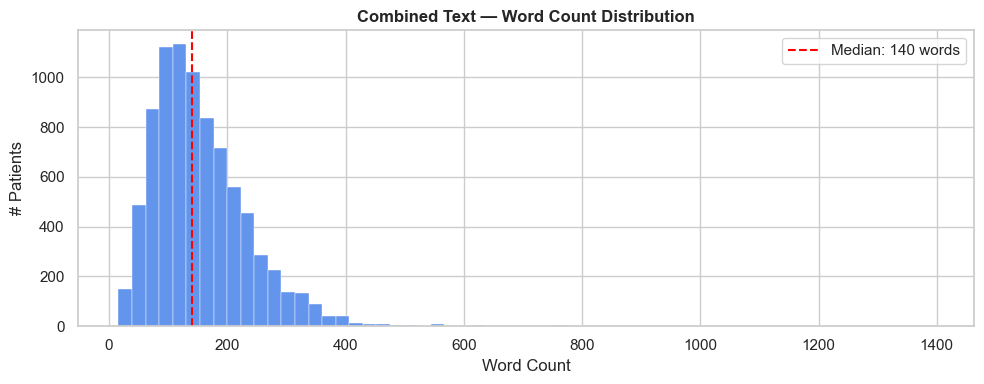

In [42]:
# ── 6.4  Text — combined_text Word Count Distribution ─────────────────────────
wc = df['combined_text_word_count']
print("combined_text word count percentiles:")
print(f"  50th: {wc.quantile(0.50):.0f} words")
print(f"  90th: {wc.quantile(0.90):.0f} words")
print(f"  99th: {wc.quantile(0.99):.0f} words")

zero_text = (wc == 0).sum()
if zero_text > 0:
    print(f"\nWARNING: {zero_text} rows have combined_text_word_count == 0 (no clinical text)!")
    print(df[wc == 0][['stay_id', 'triage', 'chiefcomplaint', 'HPI', 'past_medical_history']].head())
else:
    print("\nAll rows have at least some clinical text (combined_text_word_count > 0)")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(wc[wc > 0], bins=60, color='cornflowerblue', edgecolor='white', linewidth=0.3)
ax.axvline(wc.median(), color='red', linestyle='--', linewidth=1.5,
           label=f'Median: {wc.median():.0f} words')
ax.set_title('Combined Text — Word Count Distribution', fontweight='bold')
ax.set_xlabel('Word Count')
ax.set_ylabel('# Patients')
ax.legend()
plt.tight_layout()
plt.show()

In [43]:
# ── 6.5  Text — Validation ────────────────────────────────────────────────────
text_cols = ['combined_text', 'chiefcomplaint', 'HPI', 'past_medical_history']
text_stat_cols = ['cc_char_len', 'hpi_word_count', 'pmh_word_count',
                  'combined_text_word_count', 'pmh_has_content']

assert df['combined_text'].isna().sum() == 0, "combined_text has NaN values"
assert df[text_stat_cols].isna().sum().sum() == 0, "Unexpected NaN in text stat cols"

print("Null counts (text cols):")
print(df[text_cols + text_stat_cols].isna().sum().to_string())

print("\nSample combined_text by triage level:")
for level in [1, 2, 3]:
    sample = df[df['triage'] == level]['combined_text'].iloc[0]
    print(f"\n  [L{level}] {sample[:200]}...")

Null counts (text cols):
combined_text               0
chiefcomplaint              0
HPI                         0
past_medical_history        0
cc_char_len                 0
hpi_word_count              0
pmh_word_count              0
combined_text_word_count    0
pmh_has_content             0

Sample combined_text by triage level:

  [L1] abdominal pain. [REDACTED] male with hx of htn, PE here with abd pain.
Pt reports that [REDACTED] days ago he began to have a burning in the
epigastric area. Over time, it increased to a fire with
rad...

  [L2] LETHARGY/shortness of breath. Patient is an [REDACTED] year-old patient with history of Sjogren's
syndrome, moderate MR, recent hospitalization for sepsis
secondary to c. diff colitis complicated by h...

  [L3] R Leg pain. [REDACTED] w Rt AK pop to [REDACTED] bypass with NRGSV for a thrombosed
popliteal aneurysm in [REDACTED] present with worsening new onset
right foot claudication. Past Medical History: PMH...


## Section 7 — Target Variable Analysis

Class distribution, inverse-frequency class weights, and 0-indexed encoded target.

In [44]:
# ── 7.1  Target — Class Distribution & Weights ────────────────────────────────
assert df['triage'].isna().sum() == 0, "triage has unexpected nulls!"
assert set(df['triage'].unique()).issubset({1, 2, 3, 4}), "triage contains unexpected values!"

N = len(df)
K = 4
triage_counts = df['triage'].value_counts().sort_index()
triage_pct    = triage_counts / N * 100

print("Triage class distribution:")
for level, count in triage_counts.items():
    label = {1: 'Critical', 2: 'Emergent', 3: 'Urgent', 4: 'Less Urgent'}[level]
    print(f"  L{level} ({label}): {count:,} ({triage_pct[level]:.1f}%)")

# Inverse-frequency class weights: w_k = N / (K * n_k)
class_weights = {level: N / (K * count) for level, count in triage_counts.items()}
print("\nInverse-frequency class weights (for use in loss function):")
for level, weight in class_weights.items():
    print(f"  L{level}: {weight:.4f}")

# 0-indexed target for PyTorch/sklearn compatibility
df['triage_encoded'] = df['triage'] - 1  # 0=Critical, 1=Emergent, 2=Urgent, 3=Less Urgent
print("\ntriage_encoded distribution (0-indexed):")
print(df['triage_encoded'].value_counts().sort_index().rename(
    {0: '0-Critical', 1: '1-Emergent', 2: '2-Urgent', 3: '3-Less Urgent'}
).to_string())

Triage class distribution:
  L1 (Critical): 502 (6.0%)
  L2 (Emergent): 3,100 (37.0%)
  L3 (Urgent): 4,724 (56.4%)
  L4 (Less Urgent): 57 (0.7%)

Inverse-frequency class weights (for use in loss function):
  L1: 4.1748
  L2: 0.6760
  L3: 0.4436
  L4: 36.7675

triage_encoded distribution (0-indexed):
triage_encoded
0-Critical        502
1-Emergent       3100
2-Urgent         4724
3-Less Urgent      57


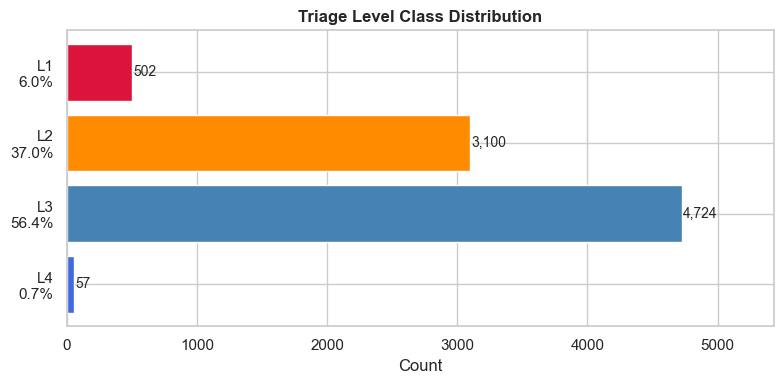

In [45]:
# ── 7.2  Target — Class Distribution Plot ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['crimson', 'darkorange', 'steelblue', 'royalblue']
labels = [f"L{l}\n{triage_pct[l]:.1f}%" for l in triage_counts.index]
bars = ax.barh(labels[::-1], triage_counts.values[::-1], color=colors[::-1], edgecolor='white')
for bar, count in zip(bars, triage_counts.values[::-1]):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{count:,}', va='center', fontsize=10)
ax.set_xlabel('Count')
ax.set_title('Triage Level Class Distribution', fontweight='bold')
ax.set_xlim(0, triage_counts.max() * 1.15)
plt.tight_layout()
plt.show()

## Section 8 — Final Assembly & Validation

Column inventory, null checks, shape assertions, and grouped column listing.

In [46]:
# ── 8.1  Final Assembly — Column Inventory ────────────────────────────────────
print("=== Final Column Inventory ===")
print(f"Shape: {df.shape}")

col_groups = {
    'Identifiers':          ['stay_id'],
    'Target':               ['triage', 'triage_encoded'],
    'Vital signs (raw)':    ['temp_f', 'heart_rate', 'resp_rate', 'spo2', 'sbp', 'dbp'],
    'Vital signs (scaled)': ['temp_f_scaled', 'heart_rate_scaled', 'resp_rate_scaled',
                             'spo2_scaled', 'sbp_scaled', 'dbp_scaled'],
    'Vital derived':        ['shock_index', 'pulse_pressure', 'map'],
    'Vital binary flags':   ['spo2_abnormal', 'hr_tachycardia', 'rr_tachypnea',
                             'temp_fever', 'temp_hypothermia', 'hypotension',
                             'vital_abnormality_count', 'vitals_any_missing', 'vitals_out_of_range'],
    'Clinical scores':      ['news2_score', 'news2_risk', 'qsofa_score', 'mews_score'],
    'Demographics':         ['age', 'age_scaled', 'age_group'],
    'Gender (one-hot)':     ['gender_female', 'gender_male'],
    'Race (one-hot)':       ['race_white', 'race_black', 'race_hispanic', 'race_asian', 'race_other'],
    'Transport':            ['transport_ordinal', 'transport_walkin', 'transport_ambulance',
                             'transport_helicopter', 'transport_unknown'],
    'Pain':                 ['pain', 'pain_imputed', 'pain_scaled', 'pain_severity',
                             'pain_missing', 'pain_x_transport'],
    'Text':                 ['combined_text', 'chiefcomplaint', 'HPI', 'past_medical_history'],
    'Text statistics':      ['cc_char_len', 'hpi_word_count', 'pmh_word_count',
                             'combined_text_word_count', 'pmh_has_content'],
}

for group, cols in col_groups.items():
    missing = [c for c in cols if c not in df.columns]
    status = "OK" if not missing else f"MISSING: {missing}"
    print(f"\n  [{status}] {group} ({len(cols)} cols):")
    print(f"    {cols}")

=== Final Column Inventory ===
Shape: (8383, 66)

  [OK] Identifiers (1 cols):
    ['stay_id']

  [OK] Target (2 cols):
    ['triage', 'triage_encoded']

  [OK] Vital signs (raw) (6 cols):
    ['temp_f', 'heart_rate', 'resp_rate', 'spo2', 'sbp', 'dbp']

  [OK] Vital signs (scaled) (6 cols):
    ['temp_f_scaled', 'heart_rate_scaled', 'resp_rate_scaled', 'spo2_scaled', 'sbp_scaled', 'dbp_scaled']

  [OK] Vital derived (3 cols):
    ['shock_index', 'pulse_pressure', 'map']

  [OK] Vital binary flags (9 cols):
    ['spo2_abnormal', 'hr_tachycardia', 'rr_tachypnea', 'temp_fever', 'temp_hypothermia', 'hypotension', 'vital_abnormality_count', 'vitals_any_missing', 'vitals_out_of_range']

  [OK] Clinical scores (4 cols):
    ['news2_score', 'news2_risk', 'qsofa_score', 'mews_score']

  [OK] Demographics (3 cols):
    ['age', 'age_scaled', 'age_group']

  [OK] Gender (one-hot) (2 cols):
    ['gender_female', 'gender_male']

  [OK] Race (one-hot) (5 cols):
    ['race_white', 'race_black', 'race_

In [47]:
# ── 8.2  Final Assembly — Null Checks & Shape Assertion ───────────────────────
# Raw vitals: NaN preserved (expected — do not assert zero here)
print("Raw vital null counts (NaN preserved — expected):")
print(df[VITAL_COLS].isna().sum().to_string())

# All engineered columns must have zero NaN
numeric_engineered = [
    # Scaled vitals (computed from df_vitals_proc — no NaN)
    'temp_f_scaled', 'heart_rate_scaled', 'resp_rate_scaled',
    'spo2_scaled', 'sbp_scaled', 'dbp_scaled',
    # Vital derived
    'shock_index', 'pulse_pressure', 'map',
    # Vital binary flags
    'spo2_abnormal', 'hr_tachycardia', 'rr_tachypnea',
    'temp_fever', 'temp_hypothermia', 'hypotension',
    'vital_abnormality_count', 'vitals_any_missing', 'vitals_out_of_range',
    # Clinical scores
    'news2_score', 'news2_risk', 'qsofa_score', 'mews_score',
    # Demographics
    'age', 'age_scaled', 'age_group',
    'gender_female', 'gender_male',
    'race_white', 'race_black', 'race_hispanic', 'race_asian', 'race_other',
    'transport_ordinal', 'transport_walkin', 'transport_ambulance',
    'transport_helicopter', 'transport_unknown',
    # Pain
    'pain', 'pain_imputed', 'pain_scaled', 'pain_severity',
    'pain_missing', 'pain_x_transport',
    # Text statistics
    'cc_char_len', 'hpi_word_count', 'pmh_word_count',
    'combined_text_word_count', 'pmh_has_content',
    # Target
    'triage_encoded',
]

null_counts = df[numeric_engineered].isna().sum()
null_cols = null_counts[null_counts > 0]
if len(null_cols) > 0:
    print(f"\nNaN found in {len(null_cols)} engineered columns:")
    print(null_cols.to_string())
else:
    print("\nAll engineered columns: 0 NaN")

assert df.shape[0] == 8383, f"Row count changed — expected 8383, got {df.shape[0]}"
print(f"Shape: {df.shape}  |  Total columns: {len(df.columns)}")

Raw vital null counts (NaN preserved — expected):
temp_f        169
heart_rate     18
resp_rate     115
spo2           94
sbp            32
dbp            48

All engineered columns: 0 NaN
Shape: (8383, 66)  |  Total columns: 66


## Section 9 — Save

Write the feature-engineered dataset to disk.

In [48]:
OUTPUT_KEY    = "Data_Output/consolidated_dataset_features.csv"
OUTPUT_S3_URI = f"s3://{S3_BUCKET}/{OUTPUT_KEY}"

# Serialize to an in-memory buffer and upload to S3
buffer = io.BytesIO()
df.to_csv(buffer, index=False)
buffer.seek(0)

s3.put_object(
    Bucket=S3_BUCKET,
    Key=OUTPUT_KEY,
    Body=buffer.getvalue(),
    ContentType="text/csv",
)

print(f"Saved to    : {OUTPUT_S3_URI}")
print(f"Shape       : {df.shape}")
print(f"Columns ({len(df.columns)}): {list(df.columns)}")

Saved to    : s3://ed-triage-capstone-group7/Data_Output/consolidated_dataset_features.csv
Shape       : (8383, 66)
Columns (66): ['stay_id', 'triage', 'chiefcomplaint', 'HPI', 'past_medical_history', 'initial_vitals', 'patient_info', 'pain', 'arrival_transport', 'temp_f', 'heart_rate', 'resp_rate', 'spo2', 'sbp', 'dbp', 'vitals_any_missing', 'vitals_out_of_range', 'age', 'gender', 'race', 'pain_missing', 'temp_f_scaled', 'heart_rate_scaled', 'resp_rate_scaled', 'spo2_scaled', 'sbp_scaled', 'dbp_scaled', 'shock_index', 'pulse_pressure', 'map', 'spo2_abnormal', 'hr_tachycardia', 'rr_tachypnea', 'temp_fever', 'temp_hypothermia', 'hypotension', 'vital_abnormality_count', 'news2_score', 'news2_risk', 'qsofa_score', 'mews_score', 'age_scaled', 'age_group', 'gender_female', 'gender_male', 'race_white', 'race_black', 'race_hispanic', 'race_asian', 'race_other', 'transport_ordinal', 'transport_walkin', 'transport_ambulance', 'transport_helicopter', 'transport_unknown', 'pain_imputed', 'pain_sc